# Task 3: Real-Time Echocardiogram Video Analysis



**Scenario:** ultrasound footage of a beating heart is noisy, murky, and low-contrast. This notebook builds a real-time OpenCV pipeline that reads each frame of the echo clip, applies the same mathematical enhancements used on the static X-ray/CT/MRI slices, and displays the corrected feed live alongside the raw feed.



**Sample clip:** `data/echo_sample.mp4`, one short clip from the Stanford EchoNet-Dynamic dataset.



Set `SHOW_LIVE = False` below if running headlessly (no display available, e.g. during automated grading) — frame processing and screenshot saving still run either way; only the live `cv2.imshow` window is skipped.

In [1]:
import cv2

import numpy as np

import matplotlib.pyplot as plt

import os



VIDEO_PATH = 'data/echo_sample.mp4'

OUTPUT_DIR = 'output'

os.makedirs(OUTPUT_DIR, exist_ok=True)



SHOW_LIVE = True

MAX_SCREENSHOTS = 6

## Enhancement Pipeline

The same building blocks from Task 1 (histogram equalization, JET colormap, gray-world color balance, log transform, gamma transform), applied to every frame: equalization fights murky low contrast, the colormap highlights blood-flow intensity, log transform pulls detail out of dark heart-chamber regions, and a fractional gamma suppresses blinding white ultrasound backscatter.

In [2]:
def gray_world_balance(bgr_image):

    b, g, r = cv2.split(bgr_image.astype(np.float64))

    gray_mean = (b.mean() + g.mean() + r.mean()) / 3.0

    b = np.clip(b * (gray_mean / (b.mean() + 1e-6)), 0, 255)

    g = np.clip(g * (gray_mean / (g.mean() + 1e-6)), 0, 255)

    r = np.clip(r * (gray_mean / (r.mean() + 1e-6)), 0, 255)

    return cv2.merge([b, g, r]).astype(np.uint8)





def log_transform(image):

    image_f = image.astype(np.float64)

    c = 255.0 / np.log(1 + image_f.max()) if image_f.max() > 0 else 1.0

    return np.clip(c * np.log(1 + image_f), 0, 255).astype(np.uint8)





def gamma_transform(image, gamma=0.7):

    normalized = image.astype(np.float64) / 255.0

    return np.clip(255.0 * np.power(normalized, gamma), 0, 255).astype(np.uint8)





def enhance_frame(gray_frame):

    equalized = cv2.equalizeHist(gray_frame)

    colored = cv2.applyColorMap(equalized, cv2.COLORMAP_JET)

    balanced = gray_world_balance(colored)

    logged = log_transform(balanced)

    return gamma_transform(logged, gamma=0.7)

## Video Capture Setup

Read from the provided `.mp4` file rather than a webcam.

In [3]:
cap = cv2.VideoCapture(VIDEO_PATH)

assert cap.isOpened(), f'Could not open {VIDEO_PATH}'



frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

fps = cap.get(cv2.CAP_PROP_FPS)

print(f'Frames: {frame_count} | FPS: {fps:.1f}')



screenshot_interval = max(1, frame_count // MAX_SCREENSHOTS)

Frames: 215 | FPS: 50.0


## Real-Time Video Processing Loop

Every frame is enhanced and concatenated with its raw grayscale counterpart for a live side-by-side monitoring view. A handful of evenly spaced frames are also saved to `output/` as evidence, since `cv2.imshow` only works interactively (not during headless notebook execution).

In [4]:
frame_idx = 0

saved_screenshots = 0

live_window_failed = False



while True:

    ret, frame = cap.read()

    if not ret:

        break



    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    enhanced = enhance_frame(gray)

    raw_bgr = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)

    combined = np.hstack([raw_bgr, enhanced])



    if SHOW_LIVE and not live_window_failed:

        try:

            cv2.imshow('Raw (left) vs Enhanced (right)', combined)

            if cv2.waitKey(1) & 0xFF == ord('q'):

                break

        except cv2.error:

            live_window_failed = True

            print('No display available; continuing headlessly (frames still saved to output/).')



    if frame_idx % screenshot_interval == 0 and saved_screenshots < MAX_SCREENSHOTS:

        cv2.imwrite(f'{OUTPUT_DIR}/frame_{frame_idx:04d}.png', combined)

        saved_screenshots += 1



    frame_idx += 1



cap.release()

try:

    cv2.destroyAllWindows()

except cv2.error:

    pass



print(f'Processed {frame_idx} frames, saved {saved_screenshots} screenshots to {OUTPUT_DIR}/')

Processed 215 frames, saved 6 screenshots to output/


## Preview a Saved Screenshot

Since `cv2.imshow` cannot render inline in a notebook, preview one of the saved side-by-side frames here to confirm the pipeline is working.

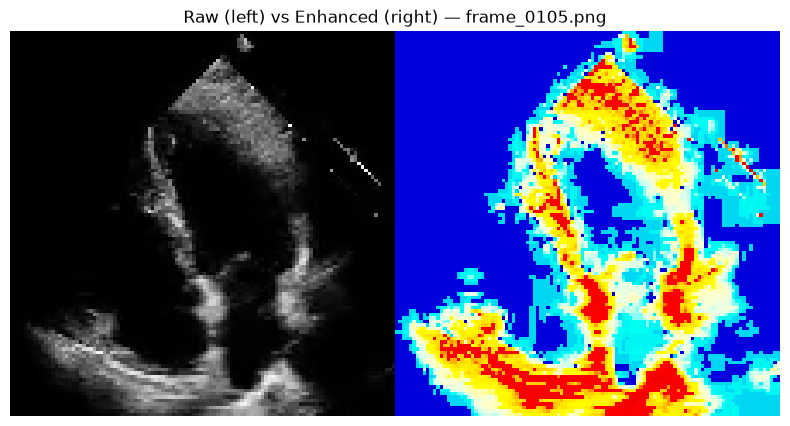

In [5]:
import glob



saved = sorted(glob.glob(f'{OUTPUT_DIR}/frame_*.png'))

assert saved, 'No screenshots were saved — check that the video loaded correctly.'



preview = cv2.imread(saved[len(saved) // 2])

plt.figure(figsize=(10, 5))

plt.imshow(cv2.cvtColor(preview, cv2.COLOR_BGR2RGB))

plt.title(f'Raw (left) vs Enhanced (right) \u2014 {os.path.basename(saved[len(saved) // 2])}')

plt.axis('off')

plt.show()

## Summary

- The pipeline reads the echo `.mp4` frame-by-frame via `cv2.VideoCapture`, never a webcam.

- Each frame is equalized, JET-colormapped, color-balanced, log-transformed, and gamma-corrected, then shown live next to the untouched raw frame.

- Log transform recovers detail inside dark heart chambers; gamma (\u03b3=0.7) suppresses blinding white ultrasound backscatter.

- A handful of representative side-by-side frames are saved to `output/` so the pipeline's effect is visible without re-running the live loop.